# *Dry Bean* dataset

[*UCI* webpage](https://archive.ics.uci.edu/dataset/602/dry+bean+dataset)

First, we import the libraries that we will need to load, process and visualize the data.

Details about the different libraries and provided functions can be found in their respective documentation:
- `numpy` for numerical calculations https://numpy.org/doc/stable/
- `pandas` for data manipulation and analysis https://pandas.pydata.org/docs/
- `pyplot` from `matplotlib` for basic plotting functionalities https://matplotlib.org/stable/
- `seaborn` for data visualization https://seaborn.pydata.org/

The first line below is a Python 'magic command' to display the plots in the notebook.
The last line is to somewhat increase the default figure width.

In [1]:
%matplotlib inline
import numpy
import pandas
import matplotlib.pyplot as plt
import seaborn

plt.rcParams["figure.figsize"] = (10, 5)

The [*Dry Bean* dataset](https://archive.ics.uci.edu/dataset/602/dry+bean+dataset) is the main example dataset used in part II of the course.

The classification task typically considered with this dataset is to predict the variety of a dry bean specimen based on measurements automatically derived from a digital image taken of it following a standardized protocol using a high-resolution camera.

The original dataset contains sixteen descriptive attributes recording physical measurements and one target attribute recording the variety of 13611 dry beans.

More details about the dataset can be found in the original publication:

> KOKLU, M. and OZKAN, I.A., (2020), “Multiclass Classification of Dry Beans Using Computer Vision and Machine Learning Techniques.” Computers and Electronics in Agriculture, 174, 105507.
DOI: [https://doi.org/10.1016/j.compag.2020.105507](https://doi.org/10.1016/j.compag.2020.105507)


We load the data from the `Dry_Bean_Dataset.xlsx` spreadsheet file using pandas's `read_excel` function.

The original dataset contains more than thirteen thousand rows but we use the `skiprows` parameter to keep only a subset for our analysis. Specifically, we keep the first and every fiftieth row. Alternatively, we can load the data from an already filtered `Dry_Bean_Dataset_small.csv` file.

Furthermore, we load the column `Class`, which contains the variety of the beans as the target attribute for classification, as a categorical variable, using the `dtype` parameter of the reading function. This means that the attribute takes values in a fixed set which can be ordered, where each distinct value is associated with an integer code. These codes can be used to create a numerical variant of the attribute. In addition the categorical data type provides a memory-efficient way to store such attributes.

In [2]:
db_targetname = "Class"
db_path = "./dry+bean+dataset/DryBeanDataset/Dry_Bean_Dataset.xlsx"
db_dtf = pandas.read_excel(db_path, skiprows=lambda x: x!=0 and x%50!=1, dtype={db_targetname: "category"})
# db_dtf = pandas.read_csv("./dry+bean+dataset/Dry_Bean_Dataset_small.csv", header=0, dtype={"class": "category"}).rename(columns={"class": db_targetname})
# db_dtf[f"{db_targetname}_num"] = db_dtf[db_targetname].cat.codes
db_dtf

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,32258,654.808,220.804030,186.277756,1.185348,0.536919,32612,202.662678,0.775806,0.989145,0.945408,0.917840,0.006845,0.002997,0.842429,0.998572,SEKER
2,33159,653.801,222.444029,189.980420,1.170879,0.520175,33415,205.473478,0.788111,0.992339,0.974810,0.923709,0.006708,0.003013,0.853238,0.999038,SEKER
3,33858,664.460,234.335001,184.139292,1.272596,0.618487,34142,207.627899,0.781254,0.991682,0.963681,0.886030,0.006921,0.002631,0.785050,0.999051,SEKER
4,34397,678.850,229.774702,190.931594,1.203440,0.556345,34776,209.274032,0.772203,0.989102,0.937957,0.910779,0.006680,0.002835,0.829519,0.998276,SEKER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268,39704,736.873,271.659919,186.481404,1.456767,0.727175,40106,224.839282,0.757739,0.989977,0.918880,0.827650,0.006842,0.001980,0.685004,0.997891,DERMASON
269,40213,745.819,273.636277,188.219270,1.453816,0.725858,40579,226.275898,0.811073,0.990981,0.908468,0.826922,0.006805,0.001963,0.683800,0.994120,DERMASON
270,40748,760.445,294.946840,176.427866,1.671770,0.801370,41191,227.776129,0.771669,0.989245,0.885484,0.772262,0.007238,0.001588,0.596388,0.997024,DERMASON
271,41472,759.287,293.567969,180.448531,1.626879,0.788781,41853,229.790754,0.794483,0.990897,0.903968,0.782751,0.007079,0.001639,0.612700,0.996789,DERMASON


The data table contains 17 columns and $\lceil \frac{13611}{50} \rceil = 273$ rows.

From the [variables table](https://archive.ics.uci.edu/dataset/602/dry+bean+dataset) and the publication, the main definitions of measurements can be summarized as follows:

- **major axis length** ($L$) The distance between the ends of the longest line that can be drawn through the bean.
- **minor axis length** ($l$) The distance between the ends of the longest line that can be drawn through the bean perpendicular to the major axis.
- **area** ($A$) The number of pixels within the boundaries of the bean.
- **convex area** ($C$) The number of pixels within the convex shell, the smallest convex polygon that contains the bean.
- **bounding box area** ($B$) The number of pixels within the bounding box, the smallest rectangle that contains the bean.
- **perimeter** ($P$): The length of the boundary of the bean.
- **eccentricity** ($Ec$) The eccentricity of the ellipse having the same moments as the bean.
- **extent** ($Ex$) The ratio of the number of pixels in the bounding box to those within the bean boundaries, $Ex = A/B$.
- **solidity** ($S$) The ratio of the number of pixels in the convex shell to those within the bean boundaries, $S = A/C$.
- **roundness** ($R$) $R = (4 \pi A)/P^2$
- **shape factor 2** ($SF2$) $SF2 = l/A$
- **shape factor 4** ($SF4$) $SF4 = A/(L/2 \cdot l/2 \cdot \pi)$

We show descriptive statistics. The `Class` variable, containing strings, is automatically excluded by default.

Since all other attributes are numerical, for each of them the summary includes the number of values (`count`, which is equal to the number of samples since no values are missing), the average value (`mean`), the standard deviation (`std`), the minimum and maximum values (`min` and `max`, respectively), as well as the 25th, 50th and 75th percentiles (`25%`, `50%` and `75%`, respectively).

Recall that the *x*th percentile is the threshold such that *x* percent of values fall below it. In particular, the 50th percentile is the threshold such that fifty percent of values fall below it, and hence half of values are above. It is also known as the *median*.

In [3]:
db_dtf.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000
mean,53232.278388,858.173322,320.668254,202.502848,1.584150,0.751944,53965.285714,253.426243,0.751571,0.986999,0.871204,0.799576,0.006558,0.001713,0.643063,0.995068
std,29612.075335,217.525410,85.824118,45.818225,0.247152,0.088447,30072.653087,59.713000,0.048338,0.004429,0.065821,0.061281,0.001119,0.000596,0.097920,0.003743
min,22449.000000,554.779000,202.216250,141.828980,1.134141,0.471765,22712.000000,169.064942,0.590446,0.959374,0.601979,0.656273,0.003120,0.000688,0.430695,0.982412
25%,36365.000000,706.275000,254.568272,174.902197,1.427524,0.713639,36680.000000,215.177499,0.717934,0.984655,0.830048,0.761236,0.005949,0.001139,0.579480,0.993613
50%,44628.000000,796.436000,297.981992,192.491117,1.549023,0.763703,45099.000000,238.373938,0.760081,0.988059,0.885125,0.801277,0.006659,0.001665,0.642044,0.996346
75%,61453.000000,988.821000,374.808751,215.381472,1.708661,0.810850,62238.000000,279.721987,0.787423,0.989977,0.918985,0.835714,0.007297,0.002183,0.698418,0.997754
max,218738.000000,1810.955000,682.465547,412.081448,2.296656,0.900230,223507.000000,527.736555,0.850744,0.993440,0.974810,0.938185,0.009008,0.003147,0.880191,0.999487


We see that attributes are on fairly different scales, from `ConvexArea` which takes values between 30072 and 223507 pixels, with an average of about 53965, to `ShapeFactor2` which takes values between 0.001713 and 0.003147, with an average of about 0.001713.

Next, we plot the correlation matrix, showing the correlation between every pair of descriptive attributes.

We display values as signed percentages, for better readability. We use the `coolwarm` color map, scaled from -100 to 100, the full range of possible values, so that bright blue and red represent respectively strong negative and strong positive correlations, while intermediate correlation values are depicted with more muted shades, with gray indicating a correlation equal to zero, i.e. a pair of variables that are not linearly dependent.

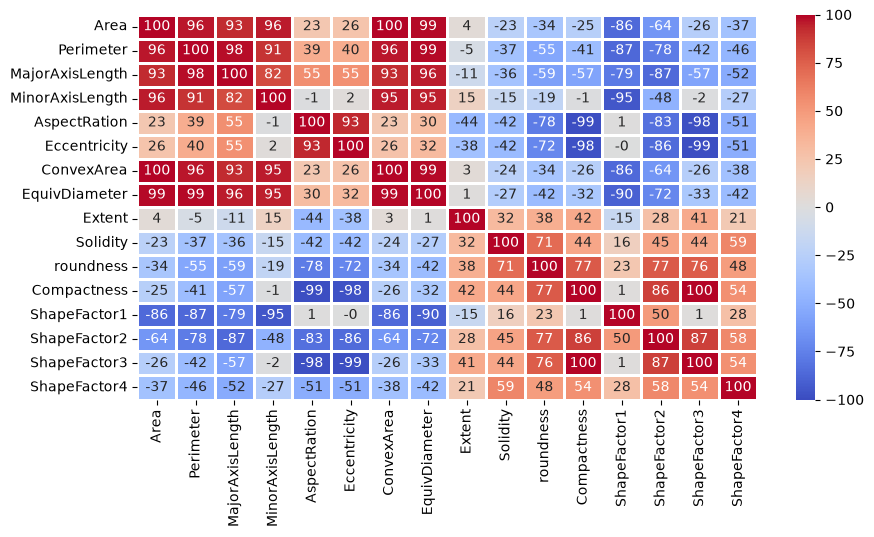

In [4]:
crm = db_dtf.drop(columns=[db_targetname]).corr()
seaborn.heatmap(100*crm,
                linewidth=.8, vmin=-100, vmax=100,
                annot=True, fmt=".0f", cmap="coolwarm");

We see that some pairs of variables are very strongly correlated either positively or negatively, with absolute several values of correlation above 0.95. For example, `Eccentricity` and `ShapeFactor3` are almost perfectly negatively correlated, having a correlation of 0.99.

For further analysis, we select a subset of attributes with limited pairwise correlations. In particular, we select the six attributes `MajorAxisLength`, `MinorAxisLength`, `Eccentricity`, `roundness`, `Extent`, `ShapeFactor2`. We narrow down our dataset accordingly.

In [5]:
db_atts = [c for c in db_dtf.columns if c != db_targetname]
db_6atts = ["MajorAxisLength", "MinorAxisLength", "Eccentricity", "roundness", "Extent", "ShapeFactor2"]
db_dtf[db_6atts+[db_targetname]]

,MajorAxisLength,MinorAxisLength,Eccentricity,roundness,Extent,ShapeFactor2,Class
0,208.178117,173.888747,0.549812,0.958027,0.763923,0.003147,SEKER
1,220.804030,186.277756,0.536919,0.945408,0.775806,0.002997,SEKER
2,222.444029,189.980420,0.520175,0.974810,0.788111,0.003013,SEKER
3,234.335001,184.139292,0.618487,0.963681,0.781254,0.002631,SEKER
4,229.774702,190.931594,0.556345,0.937957,0.772203,0.002835,SEKER
...,...,...,...,...,...,...,...
268,271.659919,186.481404,0.727175,0.918880,0.757739,0.001980,DERMASON
269,273.636277,188.219270,0.725858,0.908468,0.811073,0.001963,DERMASON
270,294.946840,176.427866,0.801370,0.885484,0.771669,0.001588,DERMASON
271,293.567969,180.448531,0.788781,0.903968,0.794483,0.001639,DERMASON


For visualizing the data, we will make scatter plots for pairs of attributes. Having six attributes corresponds to fifteen unordered pairs ($(6 \cdot 5)/2$), which would be rather overwhelming if we would plot them all. So we define a list of nine pairs of attributes, which is convenient for plotting in a three-by-three grid.

In [6]:
db_9attpairs = [
    ("MajorAxisLength", "MinorAxisLength"), ("Eccentricity", "MinorAxisLength"), ("roundness","MinorAxisLength"),
    ("MajorAxisLength", "Extent"), ("Eccentricity", "MajorAxisLength"), ("roundness", "MajorAxisLength"),
    ("MajorAxisLength", "ShapeFactor2"), ("Extent", "ShapeFactor2"), ("roundness", "Eccentricity")
]

We select colors to use for plotting the data points grouped by bean variety or otherwise.

In [7]:
db_groupcolors = [
    "#1965B0", "#DC050C", "#F7F056", "#4EB265", "#7BAFDE",
    "#CAE0AB", "#882E72", "#EE8026", "#72190E"
]
seaborn.color_palette(db_groupcolors)

[(0.09803921568627451, 0.396078431372549, 0.6901960784313725),
 (0.8627450980392157, 0.0196078431372549, 0.047058823529411764),
 (0.9686274509803922, 0.9411764705882353, 0.33725490196078434),
 (0.3058823529411765, 0.6980392156862745, 0.396078431372549),
 (0.4823529411764706, 0.6862745098039216, 0.8705882352941177),
 (0.792156862745098, 0.8784313725490196, 0.6705882352941176),
 (0.5333333333333333, 0.1803921568627451, 0.4470588235294118),
 (0.9333333333333333, 0.5019607843137255, 0.14901960784313725),
 (0.4470588235294118, 0.09803921568627451, 0.054901960784313725)]

We define a function to draw a grid of scatter plots, given a dataset together with attributes to use as horizontal and vertical coordinates as well as for color grouping.

In [8]:
def scatter_grid(dtf, coordinates_columns, color_column=None, colors=None, per_row=3, fig_height=None, args_legend=None):
    """Draw a grid of scatter plots.

        Parameters
        ----------
        ddf: DataFrame
            The DataFrame containing the dataset to plot
        coordinates_columns: list of pairs of column names
            The pairs of columns to use as horizontal and vertical coordinates in the scatter plots
        color_column: column name
            The column to determine the groups of data points for coloring
        colors: list of color specifications (e.g. html color codes) or string
            If a list of colors is given, the different groups will be assigned a color from the list, by order of appearance
            If a string is given, it is interpreted as a name of a seaborn color palette.
        per_row: integer
            The number of plots per row
        figheight: float
            Figure height, in inches
        args_legend: dict
            The value at index i is the dict containing legend parameters for the i-th plot.
            If None, or the value at index i is None, the legend is added to the plot, with default parameters
    """

    ## Prepare the color palettes
    if color_column is None:
        color_column = numpy.ones(dtf.shape[0])
        palette = ["#888888"]
        args_legend = {}
    elif type(colors) is list:
        palette = dict([(-1, "#888888")]+[(v, colors[i%len(colors)])
                                          for (i, v) in enumerate([v for v in pandas.unique(dtf[color_column]) if v != -1])])
    else:
        palette = colors

    ## Make the scatter plots
    f, axes = plt.subplots(int(numpy.ceil(len(coordinates_columns)/per_row)), per_row)
    for ci, cc in enumerate(coordinates_columns):
        seaborn.scatterplot(dtf, x=cc[0], y=cc[1],
                        hue=color_column, palette=palette,
                        ax=axes[ci//per_row, ci%per_row], legend=(args_legend is None) or (ci in args_legend))
        if args_legend is not None and args_legend.get(ci) is not None:
            axes[ci//per_row, ci%per_row].legend(**args_legend[ci])
    if fig_height is not None:
        f.set_figheight(fig_height)
    f.tight_layout()

We apply the function to draw a three-by-three grid of scatter plots for the nine pairs of attributes we defined previously.

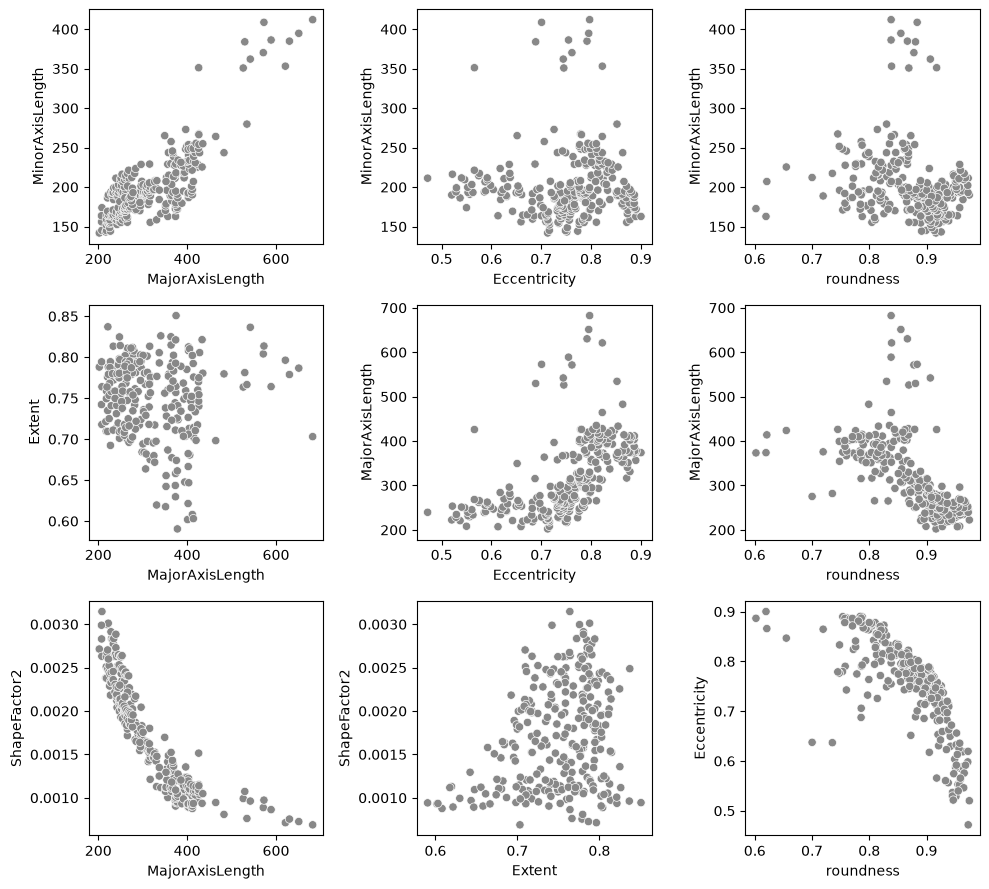

In [9]:
scatter_grid(db_dtf, db_9attpairs, fig_height=9)

We see some correlations between pairs of attributes, e.g. `MajorAxisLength` is strongly positively correlated with 'MinorAxisLength' and negatively with `ShapeFactor2`, while `roundness` and `Eccentricity` are clearly negatively correlated.

The dataset appears to have some clustering structure, as we can see some groups of points, particularly in the `MajorAxisLength` vs. `MinorAxisLength` plots for instance.

We draw the same grid of scatter plots but now with data points grouped and colored by bean variety, using the colors we defined previously.

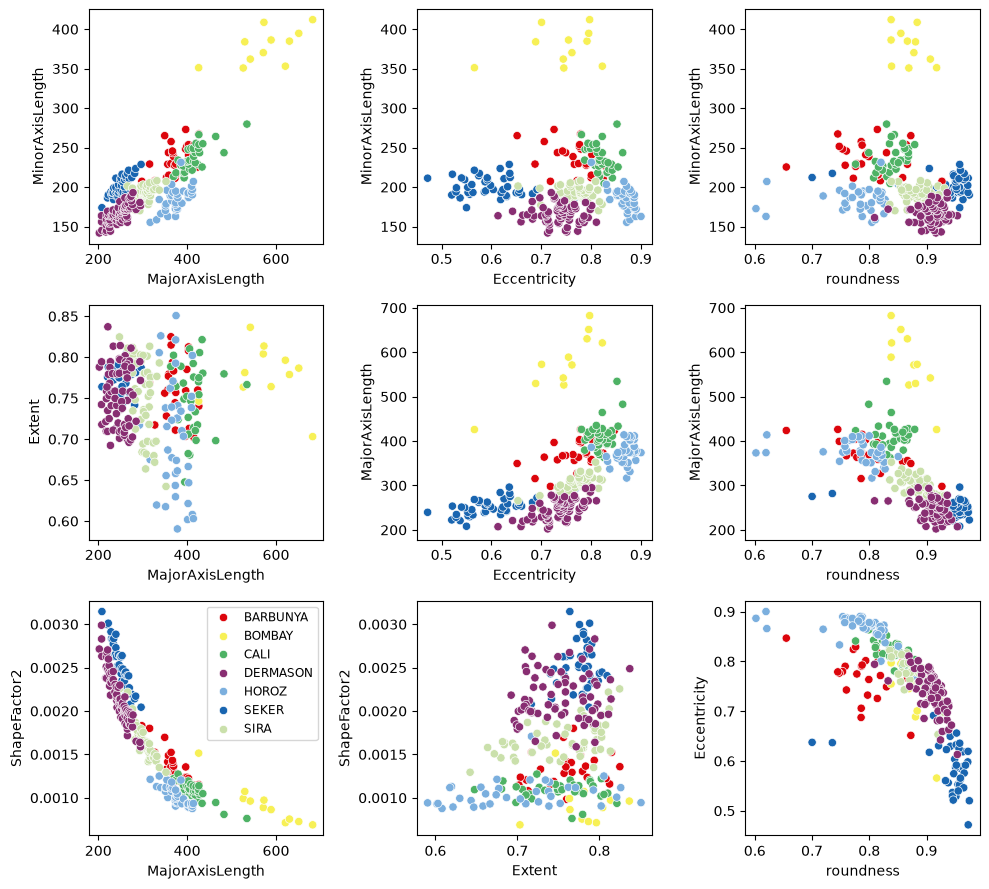

In [10]:
scatter_grid(db_dtf, db_9attpairs, db_targetname, db_groupcolors,
             fig_height=9, args_legend = {6: {"loc": "upper right", "fontsize": "small"}})

We see some overlap between clouds of points of different colors in most of the plots, for instance between *Barbunya* beans in red and *Cali* beans in green. Also, some groups show a fairly wide spread along some dimensions, such as *extent* measurements for *Horoz* beans (in light blue).
However, we clearly see clustering structure in the data that agrees with the grouping by bean variety.
*Bombay* beans (in yellow) appear to be significantly larger than beans of the other varieties.

Considering the task of classifying dry beans based on the measurements, it seems that we can hope to obtain accurate classifiers for this dataset.

Also, it should be possible to apply clustering algorithms on this dataset while leaving the class labels out, and obtain fairly cohesive clusters. We can then compare the obtained clusters to the groups formed by beans of different varieties, and hope to obtain a good agreement.